In [1]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
#CAEモデル呼び出し用のモジュール達
import torch
import torch.nn as nn
import torch.nn.init as init
from torch.utils.data import TensorDataset, DataLoader
from torchviz import make_dot
from torchsummary import summary

from sklearn import svm
from sklearn.model_selection import train_test_split

import glob
import os
import time

## データの入手、形状確認

In [3]:
all_region_latent = np.load("Cygnus_all_region_latent.npy")
bubble_region_latent = np.load("Cygnus_bubble_region_latent.npy")
print(f"データの形状:\n 全領域➡{all_region_latent.shape} \nバブル領域➡{bubble_region_latent.shape}")

データの形状:
 全領域➡(1890, 1000) 
バブル領域➡(33, 1000)


In [4]:
nan_count_to_all_region = np.isnan(all_region_latent).sum()
nan_count_to_bubble_region = np.isnan(bubble_region_latent).sum()

print(f"全領域のNaNの個数: {nan_count_to_all_region}")
print(f"バブル領域のNaNの個数: {nan_count_to_bubble_region}")

全領域のNaNの個数: 0
バブル領域のNaNの個数: 1000


In [5]:
all_filled = np.nan_to_num(all_region_latent, nan=0.0)
bubble_filled = np.nan_to_num(bubble_region_latent, nan=0.0)
print("\033[35m-形状比較-\033[0m")
print("全領域: ",all_filled.shape,)
print("バブル領域", bubble_filled.shape)

-形状比較-
全領域:  (1890, 1000)
バブル領域 (33, 1000)


In [6]:
bubble_filled[-1:,-2:]

array([[-0.6843303 ,  0.08335721]], dtype=float32)

## 潜在変数の差の分析

In [7]:
data_set_1 = all_filled  
data_set_2 = bubble_filled  

# 1. 全データを結合して全体の平均と標準偏差を計算
all_data = np.vstack((data_set_1, data_set_2))  # データを縦に結合
mean_all = np.mean(all_data, axis=0)  # 全データの各パラメータごとの平均値
std_all = np.std(all_data, axis=0)  # 全データの各パラメータごとの標準偏差

# 2. 各データセットを全体の平均と標準偏差で標準化
standardized_1 = (data_set_1 - mean_all) / std_all
standardized_2 = (data_set_2 - mean_all) / std_all

# 3. 標準化後に各データセットの平均値を計算
mean_standardized_1 = np.mean(standardized_1, axis=0)  # データセット1の各パラメータごとの平均値
mean_standardized_2 = np.mean(standardized_2, axis=0)  # データセット2の各パラメータごとの平均値

# 4. 各パラメータにおける2つのデータセット間の平均値の差を計算
mean_diff = mean_standardized_1 - mean_standardized_2

# 5. 結果を出力
#print(f"全パラメータにおけるデータセット1とデータセット2の標準化後の平均値の差: {mean_diff}")

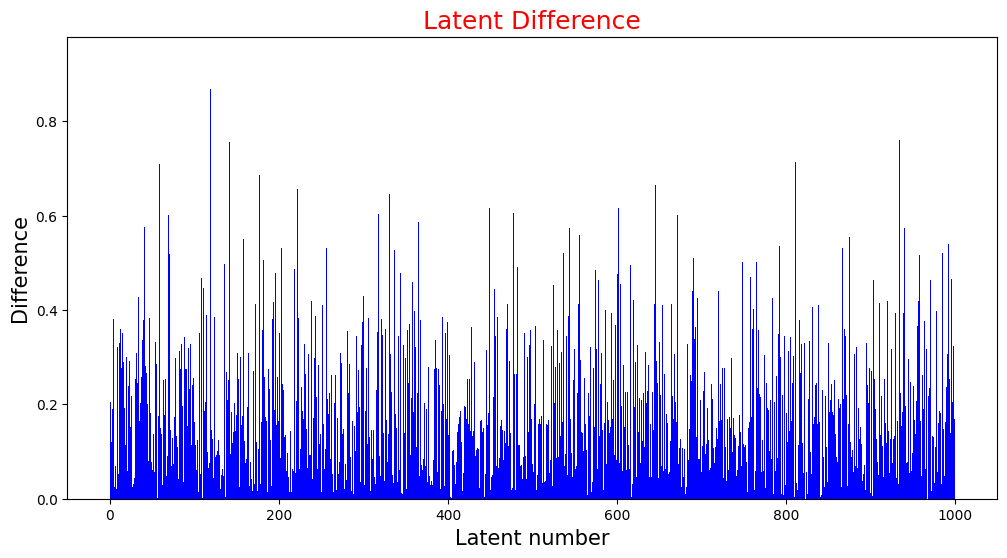

In [8]:
#両データセットの潜在変数ごとの比較結果をプロット
x = np.arange(len(mean_diff))  # 0から999までのインデックス

plt.figure(figsize=(12, 6))  # 図のサイズを指定
plt.bar(x, np.abs(mean_diff), color='blue', alpha=1, width=1.0)
plt.xlabel('Latent number', fontsize=15)
plt.ylabel('Difference', fontsize=15)
plt.title('Latent Difference', color="r", fontsize=18)
# plt.savefig("latent_difference.png")
plt.show()

## 潜在変数に有意な違いがみられる上位と下位5つの値を取り出して変化させてみる

In [9]:
#上位5つのインデックスと値を取得
sorted_indices = np.argsort(np.abs(mean_diff))[::-1]  # 降順にするために[::-1]で逆順にする

# 上位5つの値のインデックスを取得
top_5_indices = sorted_indices[:5]

# 上位5つの値を取得
top_5_values = np.abs(mean_diff)[top_5_indices]

# 結果を出力
for i, (value, index) in enumerate(zip(top_5_values, top_5_indices)):
    print(f"Top {i+1}: 値={value}, インデックス={index}")

Top 1: 値=0.9325711727142334, インデックス=673
Top 2: 値=0.8688502907752991, インデックス=119
Top 3: 値=0.7704155445098877, インデックス=401
Top 4: 値=0.7605547904968262, インデックス=934
Top 5: 値=0.7558508515357971, インデックス=141


In [10]:
# 下位5つのインデックスと値を取得
sorted_indices = np.argsort(np.abs(mean_diff))  # 昇順にソート

# 下位5つの値のインデックスを取得
bottom_5_indices = sorted_indices[:5]

# 下位5つの値を取得
bottom_5_values = np.abs(mean_diff)[bottom_5_indices]

# 結果を出力
for i, (value, index) in enumerate(zip(bottom_5_values, bottom_5_indices)):
    print(f"Bottom {i+1}: 値={value}, インデックス={index}")

Bottom 1: 値=8.364377572434023e-05, インデックス=823
Bottom 2: 値=0.00012091032112948596, インデックス=967
Bottom 3: 値=0.0006818331894464791, インデックス=828
Bottom 4: 値=0.0018169566756114364, インデックス=404
Bottom 5: 値=0.002538014203310013, インデックス=109


In [11]:
weight_path = "/home/cygnus/Downloads/FGN_CAE/CAE_3Dimension/earlystopping_flip_rot_lr0.00001.pth"
weight_para = torch.load(weight_path, map_location=torch.device('cpu'))

In [12]:
class Conv3dAutoencoder(nn.Module):
    def __init__(self):
        super(Conv3dAutoencoder, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv3d(1, 64, kernel_size=(2, 4, 4), stride=(2, 2, 2), padding=(0, 1, 1)),  # input: (1, 12, 112, 112), output: (32, 6, 56, 56)
            # nn.BatchNorm3d(64),
            nn.ReLU(True),
            nn.Conv3d(64, 32, kernel_size=(2, 4, 4), stride=(2, 2, 2), padding=(0, 1, 1)),  # input: (32, 6, 56, 56), output: (28, 28, 3, 32)
            # nn.BatchNorm3d(32),
            nn.ReLU(True),
            nn.Flatten(),  # Flatten the output to 1D latent vector
            nn.Linear(28*28*3*32, 1000)  # Adjust the size based on the flattened size
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(1000, 28*28*3*32),
            nn.Unflatten(1, (32, 3, 28, 28)),  # Unflatten back to (32, 3, 28, 28)
            nn.ConvTranspose3d(32, 16, kernel_size=(2, 4, 4), stride=(2, 2, 2), padding=(0, 1, 1)),  # output: (32, 12, 112, 112)
            # nn.BatchNorm3d(16),
            nn.ReLU(True),
            nn.ConvTranspose3d(16, 32, kernel_size=(2, 4, 4), stride=(2, 2, 2), padding=(0, 1, 1)),  # output: (32, 12, 112, 112)
            # nn.BatchNorm3d(32),
            nn.ReLU(True),
            nn.ConvTranspose3d(32, 1, kernel_size=(1, 3, 3), stride=1, padding=(0, 1, 1)), 
            nn.Sigmoid()  # to scale output between 0 and 1
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [13]:
class DataSet():
    def __init__(self, data, label):
        self.label = label
        self.data = data
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        return self.data[index], self.label[index]

In [14]:
model = Conv3dAutoencoder()
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu') 

In [15]:
model.load_state_dict(weight_para)
model.to(device)
model.eval()

Conv3dAutoencoder(
  (encoder): Sequential(
    (0): Conv3d(1, 64, kernel_size=(2, 4, 4), stride=(2, 2, 2), padding=(0, 1, 1))
    (1): ReLU(inplace=True)
    (2): Conv3d(64, 32, kernel_size=(2, 4, 4), stride=(2, 2, 2), padding=(0, 1, 1))
    (3): ReLU(inplace=True)
    (4): Flatten(start_dim=1, end_dim=-1)
    (5): Linear(in_features=75264, out_features=1000, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=1000, out_features=75264, bias=True)
    (1): Unflatten(dim=1, unflattened_size=(32, 3, 28, 28))
    (2): ConvTranspose3d(32, 16, kernel_size=(2, 4, 4), stride=(2, 2, 2), padding=(0, 1, 1))
    (3): ReLU(inplace=True)
    (4): ConvTranspose3d(16, 32, kernel_size=(2, 4, 4), stride=(2, 2, 2), padding=(0, 1, 1))
    (5): ReLU(inplace=True)
    (6): ConvTranspose3d(32, 1, kernel_size=(1, 3, 3), stride=(1, 1, 1), padding=(0, 1, 1))
    (7): Sigmoid()
  )
)

In [16]:
#特定のインデックスの数字の範囲を確かめる
print("\033[35m-上位5つの全データの潜在変数の最大及び最小値-\033[0m")
for i, index in enumerate(top_5_indices):
    print(f"Top{i+1} range(index={index}) => {np.min(all_data[:, index])} ~ {np.max(all_data[:, index])}")
    
print("\n")

#特定のインデックスの全領域とバブル領域の潜在変数の平均値を確かめる
print("\033[35m-上位5つの潜在変数の平均値-\033[0m")
for i, index in enumerate(top_5_indices):
    print(f"Top1 mean(index={index}) => 全領域:{np.mean(all_filled[:, index])} , バブル領域:{np.mean(bubble_filled[:, index])}")

-上位5つの全データの潜在変数の最大及び最小値-
Top1 range(index=673) => -1.8050472736358643 ~ 0.9908280372619629
Top2 range(index=119) => -1.5691578388214111 ~ 1.5697352886199951
Top3 range(index=401) => -1.8727304935455322 ~ 0.7742317318916321
Top4 range(index=934) => -6.797841548919678 ~ 3.0230088233947754
Top5 range(index=141) => -1.498525619506836 ~ 2.1177845001220703


-上位5つの潜在変数の平均値-
Top1 mean(index=673) => 全領域:-0.19407659769058228 , バブル領域:-0.46935179829597473
Top1 mean(index=119) => 全領域:0.25215965509414673 , バブル領域:0.4918299615383148
Top1 mean(index=401) => 全領域:-0.24298764765262604 , バブル領域:-0.479896605014801
Top1 mean(index=934) => 全領域:-0.18162374198436737 , バブル領域:-0.9335778951644897
Top1 mean(index=141) => 全領域:0.12016100436449051 , バブル領域:0.40209677815437317


In [17]:
#潜在変数に違いがある上位5つの値を-10から10まで変化させてみる。
latent_range = np.arange(-10, 15, 5)
top = 0
for latent_num in top_5_indices:
    top += 1
    index_to_set = latent_num
    latent_vector = torch.zeros(1, 1000).to(device)

    fig, axes = plt.subplots(5, 12, figsize=(3*12, 3*5))
    for latent_value in range(len(latent_range)):
        latent_vector[0, index_to_set] = latent_range[latent_value]

        with torch.no_grad():
            generated_image = model.decoder(latent_vector)
    
        # 生成した画像をnumpy配列に変換
        generated_image_np = generated_image.cpu().numpy()
        generated_image_np = generated_image_np.squeeze() 
    
        for j in range(len(generated_image_np)):
            axes[latent_value, j].imshow(generated_image_np[j])
            axes[latent_value, j].axis("off")

        axes[latent_value, 0].text(-10, 56, f'{latent_range[latent_value]}', fontsize=30, ha='right')
        
    fig.suptitle(f"Top{top}, latent_number={latent_num}", fontsize=50)
    plt.tight_layout()
    #plt.savefig(f"Top{top}.png")
    plt.show()

In [18]:
bottom = 0
for latent_num in bottom_5_indices:
    bottom += 1
    index_to_set = latent_num
    latent_vector = torch.zeros(1, 1000).to(device)

    fig, axes = plt.subplots(5, 12, figsize=(3*12, 3*5))
    for latent_value in range(len(latent_range)):
        latent_vector[0, index_to_set] = latent_range[latent_value]

        with torch.no_grad():
            generated_image = model.decoder(latent_vector)
    
        # 生成した画像をnumpy配列に変換
        generated_image_np = generated_image.cpu().numpy()
        generated_image_np = generated_image_np.squeeze() 
    
        for j in range(len(generated_image_np)):
            axes[latent_value, j].imshow(generated_image_np[j])
            axes[latent_value, j].axis("off")

        axes[latent_value, 0].text(-10, 56, f'{latent_range[latent_value]}', fontsize=30, ha='right')
        
    fig.suptitle(f"Bottom{bottom}, latent_number={latent_num}", fontsize=50)
    plt.tight_layout()
    # plt.savefig(f"Bottom{bottom}.png")
    plt.show()

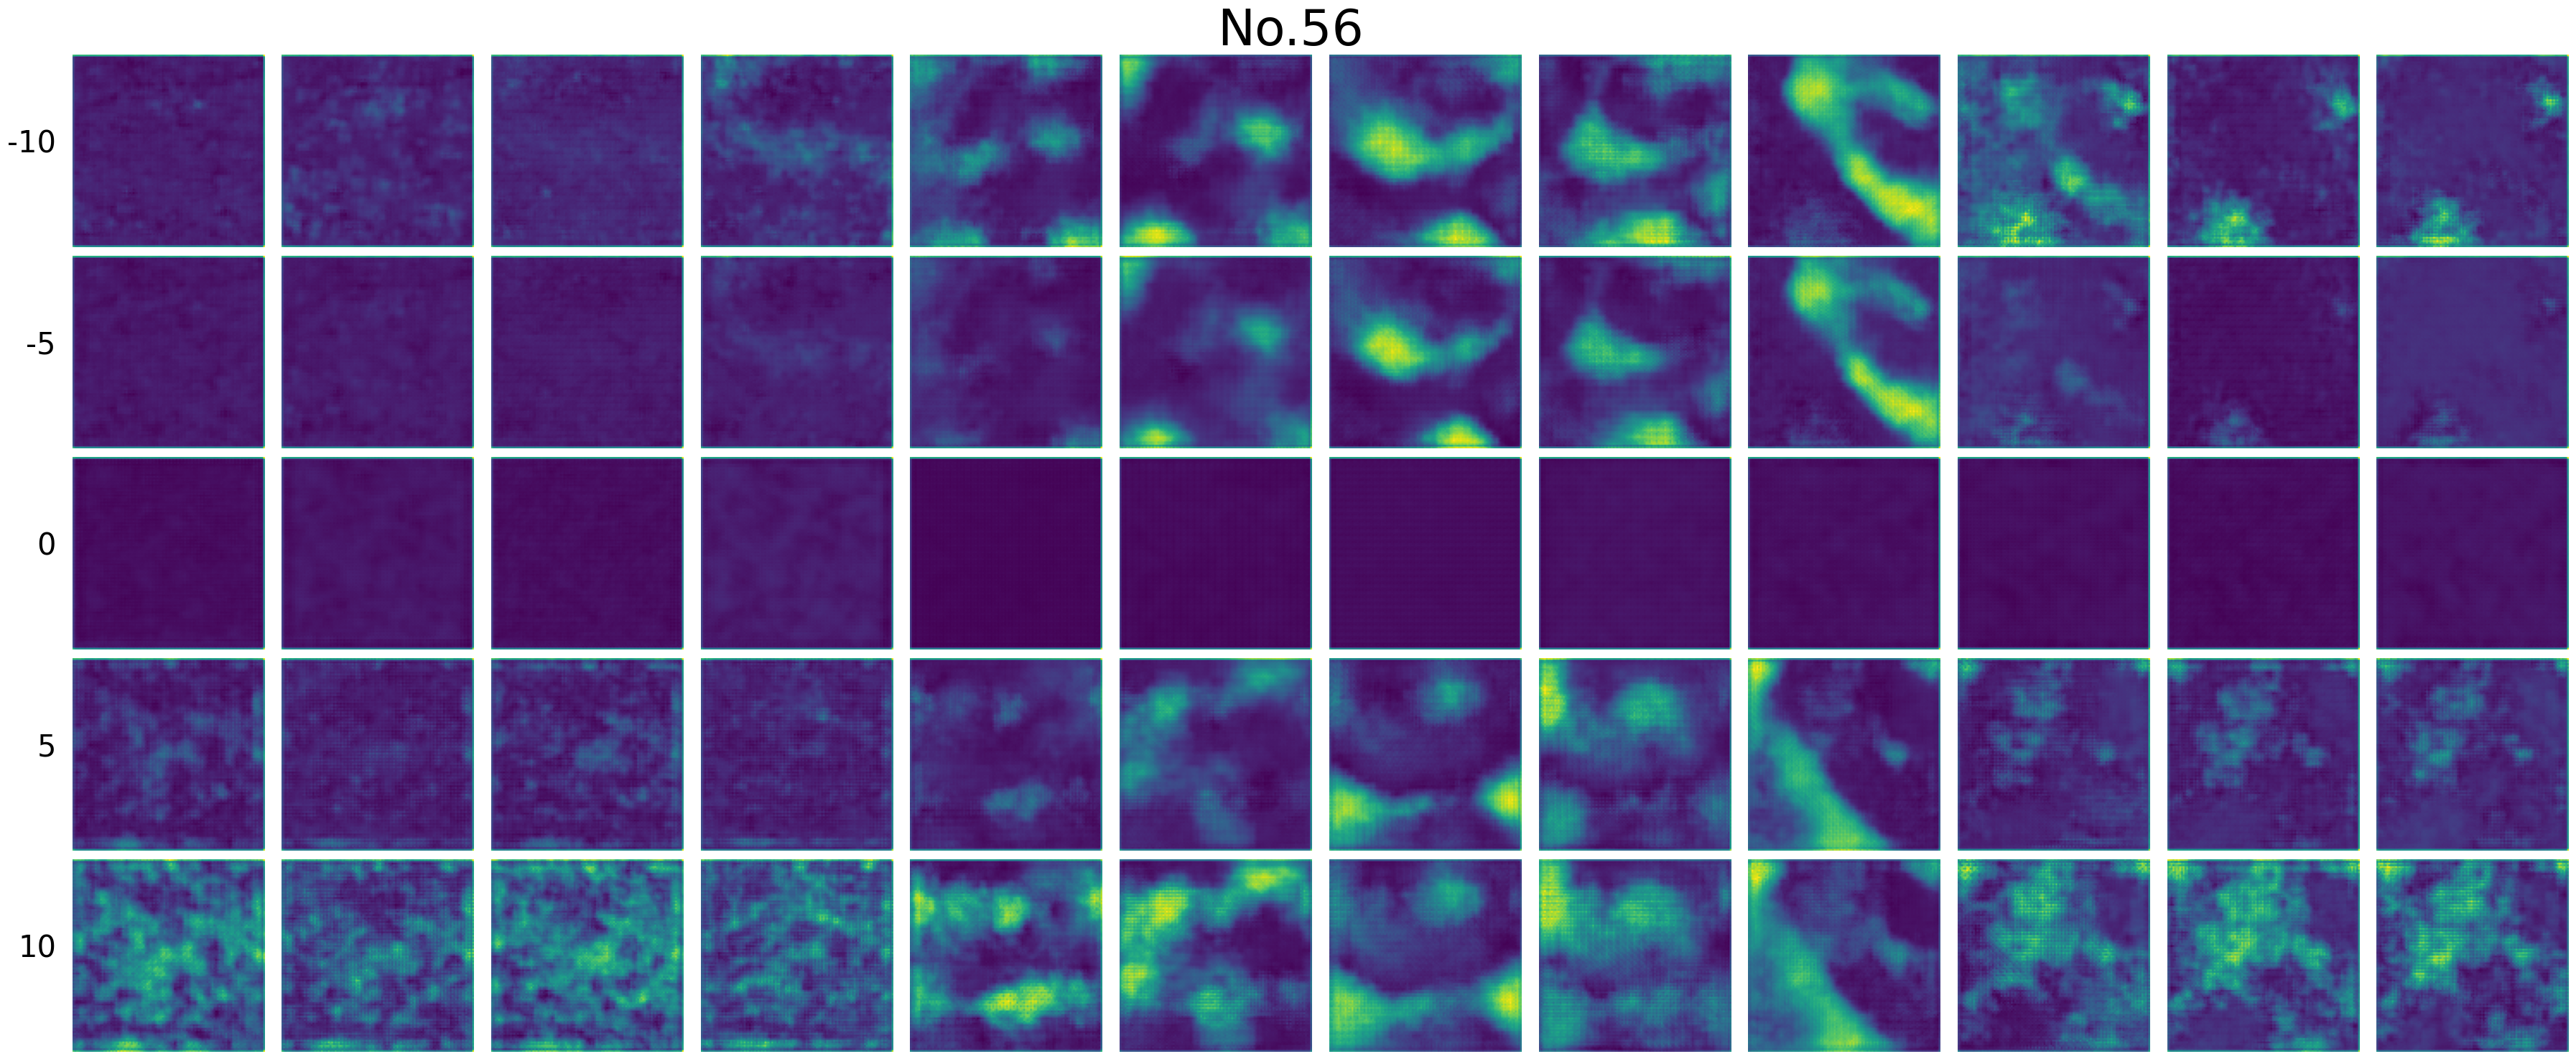

In [20]:
#適当な潜在変数の値を-10から10に変化させてみる
latent_range = np.arange(-10, 15, 5)
any_value = 56
latent_test = torch.zeros(1, 1000).to(device)

fig, axes = plt.subplots(5, 12, figsize=(3*12, 3*5))
for latent_value in range(len(latent_range)):
    latent_test[0, any_value] = latent_range[latent_value]

    with torch.no_grad():
        generated_image = model.decoder(latent_test)

    # 生成した画像をnumpy配列に変換
    generated_image_np = generated_image.cpu().numpy()
    generated_image_np = generated_image_np.squeeze() 

    for j in range(len(generated_image_np)):
        axes[latent_value, j].imshow(generated_image_np[j])
        axes[latent_value, j].axis("off")

    axes[latent_value, 0].text(-10, 56, f'{latent_range[latent_value]}', fontsize=30, ha='right')
    
fig.suptitle(f"No.{any_value}", fontsize=50)
plt.tight_layout()
#plt.savefig(f"Top{top}.png")
plt.show()

##　コルゴモロフ-スミルノフ検定

In [21]:
from scipy import stats

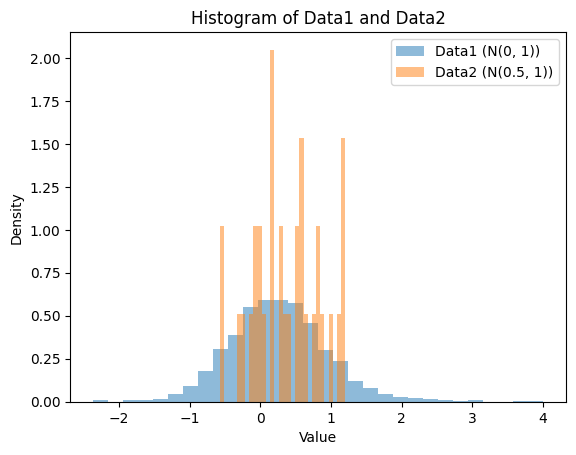

In [22]:
# 任意のデータの分布を可視化
any_latent_value = 800
data1 = all_filled[:, any_latent_value]
data2 = bubble_filled[:, any_latent_value]

plt.hist(data1, bins=30, alpha=0.5, label='Data1 (N(0, 1))', density=True)
plt.hist(data2, bins=30, alpha=0.5, label='Data2 (N(0.5, 1))', density=True)
plt.title('Histogram of Data1 and Data2')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.show()

In [23]:
# 任意のデータのコルモゴロフ-スミルノフ検定を実行
ks_statistic, p_value = stats.ks_2samp(data1, data2)

# 検定結果を表示
print(f"KS Statistic: {ks_statistic}")
print(f"P-value: {p_value}")

# p値に基づいて結論を出す
alpha = 0.05  # 有意水準
if p_value < alpha:
    print("帰無仮説を棄却します：2つの分布は異なります。")
else:
    print("帰無仮説を棄却できません：2つの分布は同じです。")

KS Statistic: 0.1797017797017797
P-value: 0.21758344806477578
帰無仮説を棄却できません：2つの分布は同じです。


In [24]:
#全潜在変数で比較
data_set_1 = all_filled
data_set_2 = bubble_filled

# コルモゴロフ-スミルノフ検定を実施
num_different_parameters = 0

for i in range(1000):  # 1000個のパラメータを比較
    ks_statistic, p_value = stats.ks_2samp(data_set_1[:, i], data_set_2[:, i])
    alpha = 0.01  # 有意水準
    if p_value < alpha:
        num_different_parameters += 1
        print(f"Parameter {i+1} is different (p-value: {p_value:.4f})")

# 異なる分布のパラメータの個数を表示
print(f"Number of parameters with different distributions: {num_different_parameters}")

Parameter 60 is different (p-value: 0.0002)
Parameter 70 is different (p-value: 0.0080)
Parameter 90 is different (p-value: 0.0029)
Parameter 119 is different (p-value: 0.0036)
Parameter 120 is different (p-value: 0.0002)
Parameter 136 is different (p-value: 0.0057)
Parameter 140 is different (p-value: 0.0010)
Parameter 142 is different (p-value: 0.0013)
Parameter 147 is different (p-value: 0.0063)
Parameter 178 is different (p-value: 0.0020)
Parameter 184 is different (p-value: 0.0030)
Parameter 201 is different (p-value: 0.0010)
Parameter 205 is different (p-value: 0.0004)
Parameter 239 is different (p-value: 0.0017)
Parameter 244 is different (p-value: 0.0013)
Parameter 257 is different (p-value: 0.0033)
Parameter 323 is different (p-value: 0.0022)
Parameter 350 is different (p-value: 0.0033)
Parameter 366 is different (p-value: 0.0000)
Parameter 368 is different (p-value: 0.0066)
Parameter 402 is different (p-value: 0.0027)
Parameter 407 is different (p-value: 0.0045)
Parameter 478